# ST3189: Machine Learning — Assessed Coursework Project
**Candidate Number:** 

---

### Structure
| Section | Task | Dataset | Models |
|---------|------|---------|--------|
| 1 | Unsupervised Learning | FIFA Players | K-Means, Hierarchical Agglomerative Clustering |
| 2 | Supervised Learning (Classification) | FIFA Players | Naive Bayes, Multinomial Logistic Regression, Random Forest |
| 3 | Supervised Learning (Regression) | FIFA Players | Linear, Polynomial, Lasso, Ridge, Random Forest |

> **Data source:** `fifa_player_performance_market_value.csv`


## Import Relevant Libraries And Read Data 
 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram

In [29]:
df = pd.read_csv("new-players-data-full.csv")
df.head()

,player_slug,version,name,full_name,description,image,height_cm,weight_kg,dob,positions,...,composure,defensive_awareness,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes,play_styles
0,rodrigo-hernandez-cascante,2025-07-17,Rodri,Rodrigo Hernández Cascante,Rodri (born 22 June 1996) is a Spanish footbal...,https://cdn.sofifa.net/players/231/866/25_120.png,190,82,1996-06-22,"CDM,CM",...,94,92,87,82,10,10,7,14,8,"Tiki Taka +,Power Shot,Long Ball Pass,Bruiser,..."
1,mohamed-salah,2025-07-17,Mohamed Salah Hamed Ghaly,Mohamed Salah Hamed Ghalyمحمد صلاح,"Mohamed Salah (Mohamed Salah Hamed Ghaly, born...",https://cdn.sofifa.net/players/209/331/25_120.png,175,72,1992-06-15,"RM,RW",...,93,38,43,41,14,14,9,11,14,"Finesse Shot +,Chip Shot,Pinged Pass,Whipped C..."
2,jude-bellingham,2025-07-17,Jude Victor William Bellingham,Jude Victor William Bellingham,Jude Bellingham (Jude Victor William Bellingha...,https://cdn.sofifa.net/players/252/371/25_120.png,186,75,2003-06-29,"CAM,CM",...,87,77,79,77,14,11,10,5,8,"Relentless +,Intercept,Slide Tackle,Technical,..."
3,erling-haaland,2025-07-17,Erling Braut Håland,Erling Braut Håland,"Erling Haaland (Erling Braut Håland, born 21 J...",https://cdn.sofifa.net/players/239/085/25_120.png,195,94,2000-07-21,ST,...,88,38,47,29,7,14,13,11,7,"Chip Shot +,Power Shot,Power Header,Bruiser,Pr..."
4,vinicius-jose-de-oliveira-junior,2025-07-17,Vini Jr.,Vinicius José Paixão de Oliveira Junior,Vini Jr. (Vinicius José Paixão de Oliveira Jun...,https://cdn.sofifa.net/players/238/794/25_120.png,176,73,2000-07-12,"LW,ST",...,83,32,25,18,5,7,7,7,10,"Quick Step +,Finesse Shot,Chip Shot,Rapid,Flai..."


In [30]:
print(df.shape)
print(df.columns.tolist())

(18773, 74)
['player_slug', 'version', 'name', 'full_name', 'description', 'image', 'height_cm', 'weight_kg', 'dob', 'positions', 'best_position', 'overall_rating', 'potential', 'value', 'wage', 'preferred_foot', 'weak_foot', 'skill_moves', 'international_reputation', 'body_type', 'real_face', 'release_clause', 'specialities', 'club_id', 'club_name', 'club_league_id', 'club_league_name', 'club_logo', 'club_position', 'club_kit_number', 'club_joined', 'club_contract_valid_until', 'country_id', 'country_name', 'country_league_id', 'country_league_name', 'country_flag', 'country_position', 'country_kit_number', 'crossing', 'finishing', 'heading_accuracy', 'short_passing', 'volleys', 'dribbling', 'curve', 'fk_accuracy', 'long_passing', 'ball_control', 'acceleration', 'sprint_speed', 'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina', 'strength', 'long_shots', 'aggression', 'interceptions', 'positioning', 'vision', 'penalties', 'composure', 'defensive_awareness', 'standin

## Select Clustering Features

In [113]:
features = [
    "weak_foot", "skill_moves", "crossing", "finishing", "heading_accuracy", "short_passing", "volleys",
    "dribbling", "curve", "fk_accuracy", "long_passing", "ball_control",
    "acceleration", "sprint_speed", "agility", "reactions", "balance",
    "shot_power", "jumping", "stamina", "strength", "long_shots",
    "aggression", "interceptions", "positioning", "vision", "penalties",
    "composure", "defensive_awareness", "standing_tackle", "sliding_tackle",
    "gk_diving", "gk_handling", "gk_kicking", "gk_positioning", "gk_reflexes"
]

data = df[features].dropna().copy()

## EDA for metrics involved


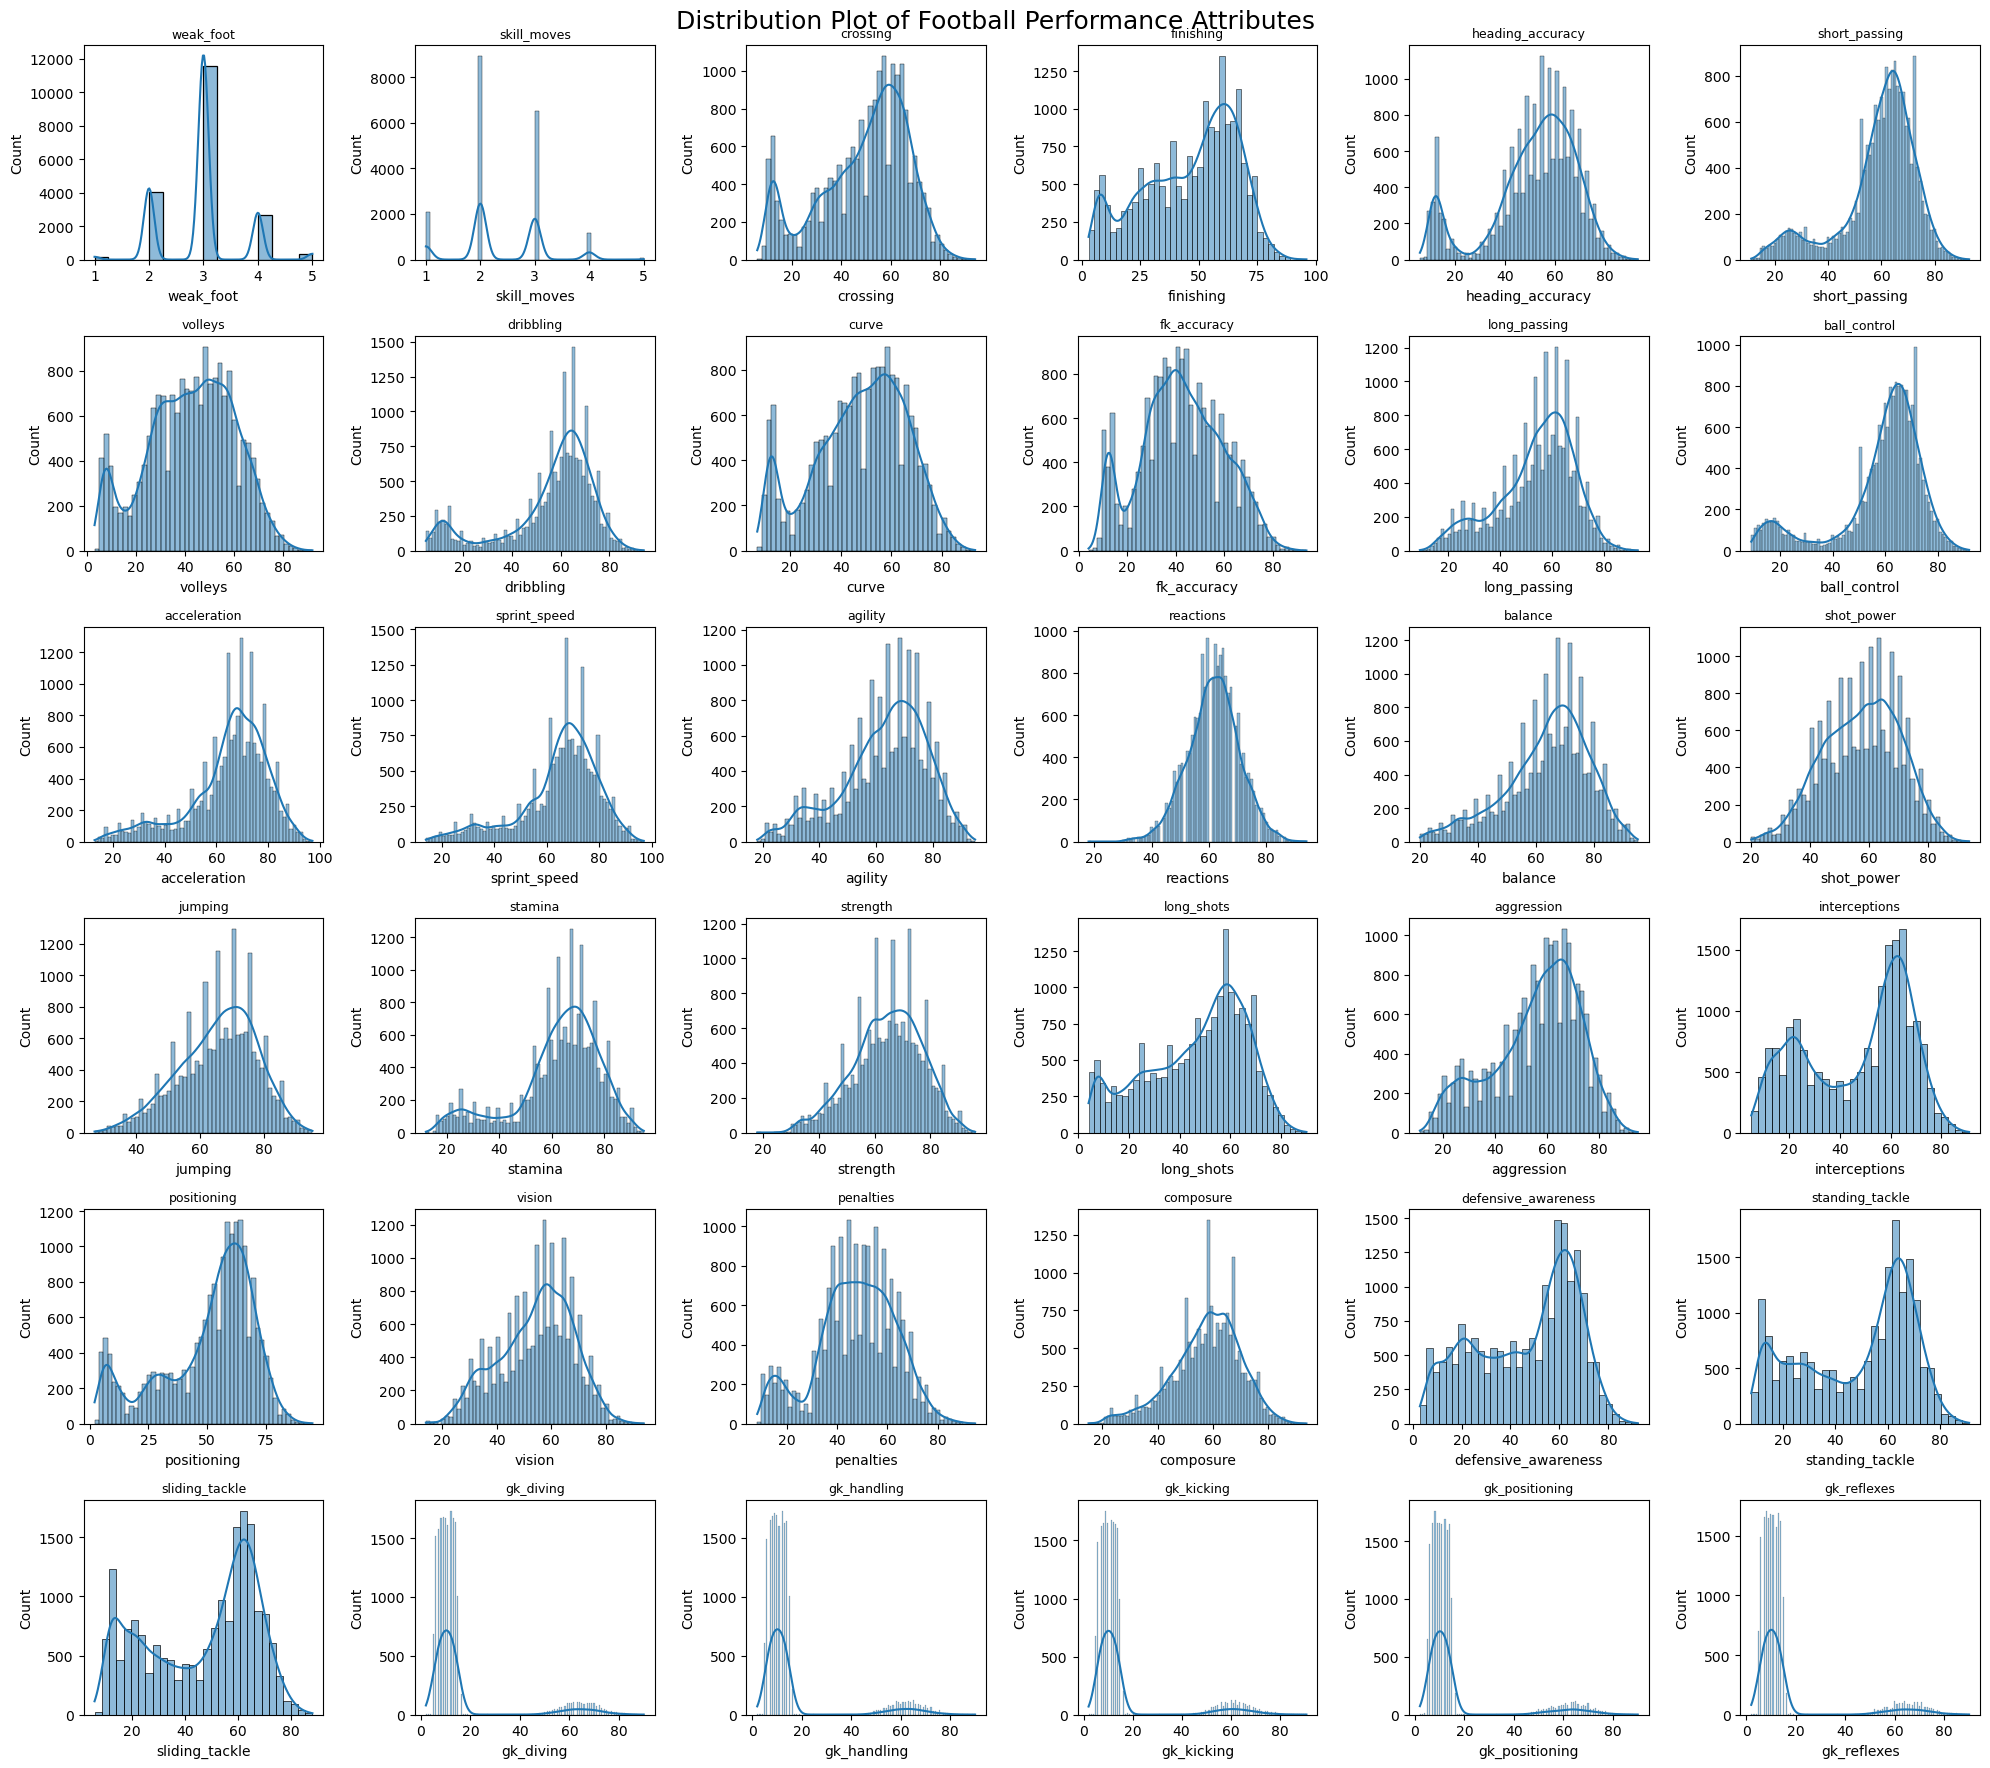

In [ ]:
plt.figure(figsize=(20,18))

for i, col in enumerate(features):
    plt.subplot(6,6,i+1)
    sns.histplot(data[col], kde=True)
    plt.title(col, fontsize=9)

plt.suptitle("Distribution Plot of Football Performance Attributes", fontsize=18)
plt.tight_layout()
plt.show()

## Standardize features


In [114]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

## Variance Plot to Determine Number of PCA Components

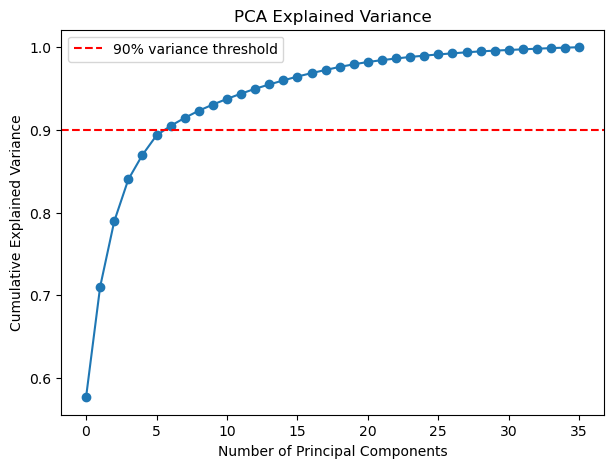

In [115]:
pca_full = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7,5))
plt.plot(cum_var, marker='o')

plt.axhline(y=0.9, color='red', linestyle='--', label='90% variance threshold')

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.show()

## Apply PCA Transformation

In [116]:
# Apply PCA using chosen number of components
pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_scaled)

print("Total variance retained:", pca.explained_variance_ratio_.sum())
print("New PCA shape:", X_pca.shape)

Total variance retained: 0.9048659661124983
New PCA shape: (18773, 7)


## Elbow Method on PCA Space

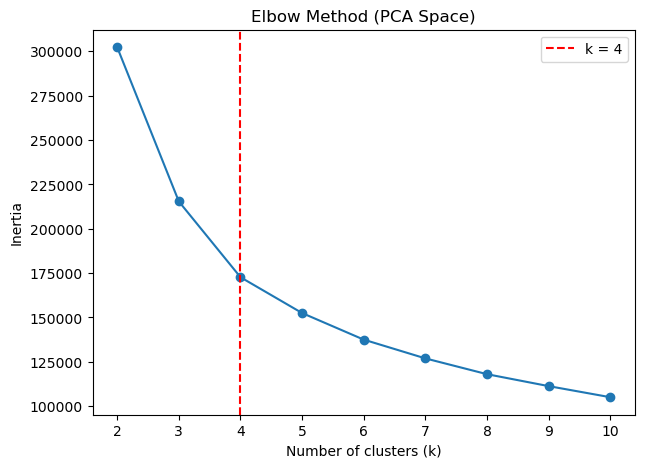

In [117]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(k_values, inertia, marker='o')
plt.axvline(x=4, color='red', linestyle='--', label='k = 4')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method (PCA Space)")
plt.legend()
plt.show()

## Silhouette Analysis on PCA Space


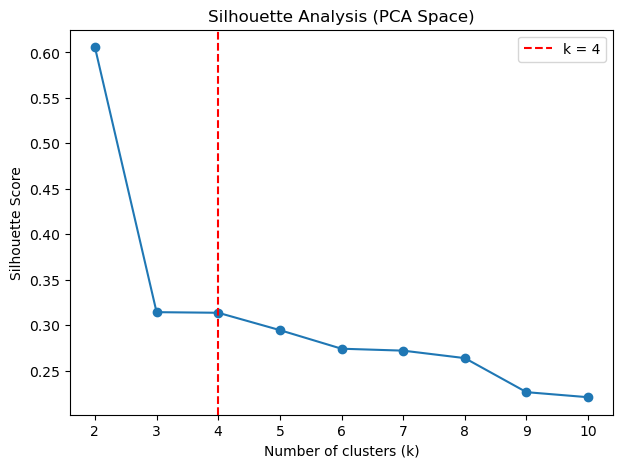

In [118]:
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pca)
    sil_scores.append(silhouette_score(X_pca, labels))

plt.figure(figsize=(7,5))
plt.plot(k_values, sil_scores, marker='o')
plt.axvline(x=4, color='red', linestyle='--', label='k = 4')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis (PCA Space)")
plt.legend()
plt.show()

## Fit Final K-Mean Model


In [119]:
k_optimal = 4

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_pca)

## Cluster Metrics


In [120]:
print("Silhouette Score:", silhouette_score(X_scaled, cluster_labels))
print("Davies-Bouldin Index:", davies_bouldin_score(X_scaled, cluster_labels))
print("Calinski-Harabasz Score:", calinski_harabasz_score(X_scaled, cluster_labels))

Silhouette Score: 0.25874061648444613
Davies-Bouldin Index: 1.3222168127918286
Calinski-Harabasz Score: 11597.393388632876


## PCA Visualisation of Clusters

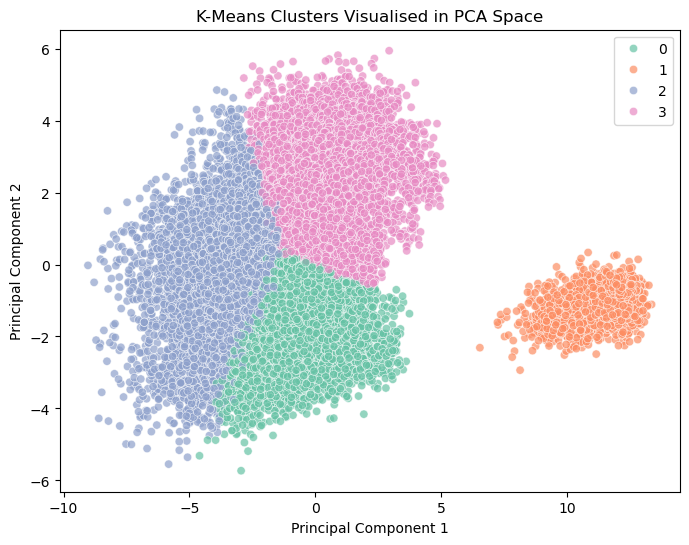

In [99]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=cluster_labels,
    palette="Set2",
    alpha=0.7
)

plt.title("K-Means Clusters Visualised in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## Cluster Size Distribution 


0    4842
1    2103
2    6116
3    5712
Name: count, dtype: int64


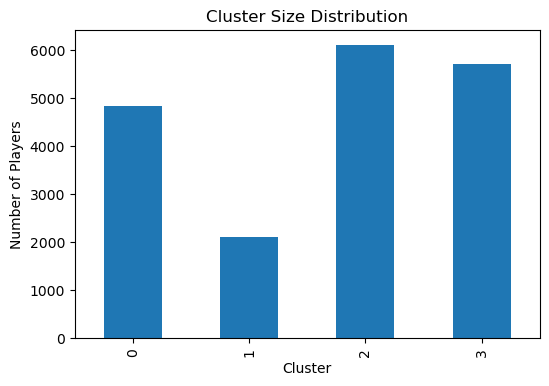

In [100]:
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print(cluster_counts)

plt.figure(figsize=(6,4))
cluster_counts.plot(kind="bar")
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Players")
plt.show()

## Profiling Using Original Variables

In [101]:
data["cluster"] = cluster_labels

cluster_profile = data.groupby("cluster")[features].mean().round(2)
cluster_profile

,weak_foot,skill_moves,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,fk_accuracy,...,penalties,composure,defensive_awareness,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
cluster,,,,,,,,,,,,,,,,,,,,,
0,3.03,2.68,50.70,60.11,51.81,58.57,52.19,62.99,51.75,45.99,...,56.50,57.06,29.95,31.41,29.46,10.12,10.09,10.12,10.06,10.07
1,2.52,1.00,13.52,9.98,13.58,28.46,10.30,12.97,14.15,13.34,...,17.83,39.21,12.23,13.44,13.34,64.60,62.61,61.81,62.91,65.35
2,3.18,2.89,64.02,60.03,58.49,70.53,55.02,69.65,63.80,57.07,...,57.18,68.15,57.96,60.36,57.10,10.30,10.35,10.37,10.34,10.32
3,2.78,2.04,44.96,33.85,58.42,58.56,32.42,50.96,39.66,34.46,...,40.19,54.28,60.48,63.09,61.15,10.22,10.23,10.12,10.18,10.14


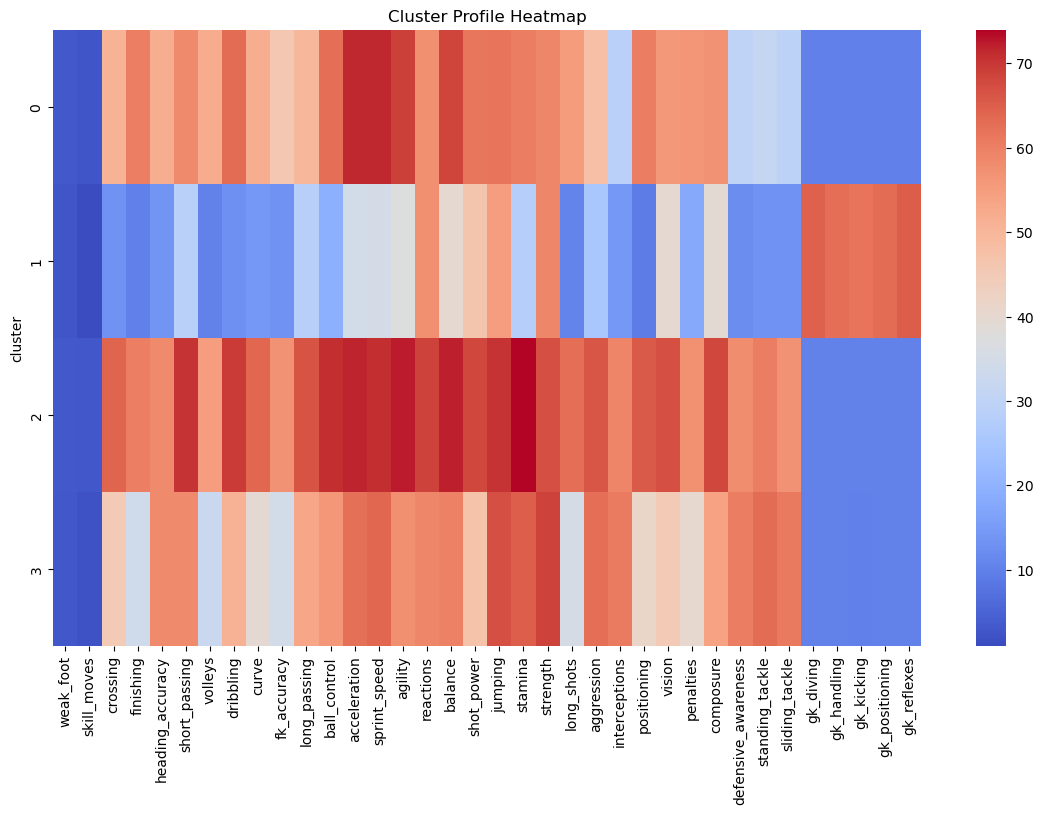

In [102]:
plt.figure(figsize=(14,8))
sns.heatmap(cluster_profile, cmap="coolwarm")
plt.title("Cluster Profile Heatmap")
plt.show()

## Validate Clusters with Actual Positions 

In [103]:
df_clean = df.loc[data.index].copy()
df_clean["cluster"] = cluster_labels

position_table = pd.crosstab(df_clean["best_position"], df_clean["cluster"], normalize="index")
position_table

cluster,0,1,2,3
best_position,,,,
CAM,0.444847,0.0,0.490741,0.064412
CB,0.000000,0.0,0.114667,0.885333
CDM,0.000765,0.0,0.592508,0.406728
CF,0.358974,0.0,0.641026,0.000000
CM,0.023156,0.0,0.813036,0.163808
GK,0.000000,1.0,0.000000,0.000000
LB,0.017526,0.0,0.445361,0.537113
LM,0.532276,0.0,0.414496,0.053228
LW,0.653179,0.0,0.346821,0.000000


In [104]:
def map_position_group(pos):
    if pos == "GK":
        return "Goalkeeper"
    elif pos in ["CB","LB","RB","LWB","RWB"]:
        return "Defender"
    elif pos in ["CDM","CM","CAM","LM","RM"]:
        return "Midfielder"
    elif pos in ["ST","CF","LW","RW"]:
        return "Forward"
    else:
        return "Other"

df_clean["position_group"] = df_clean["best_position"].apply(map_position_group)

group_table = pd.crosstab(df_clean["position_group"], df_clean["cluster"], normalize="index")
group_table

cluster,0,1,2,3
position_group,,,,
Defender,0.007084,0.0,0.242473,0.750443
Forward,0.752896,0.0,0.240669,0.006435
Goalkeeper,0.000000,1.0,0.000000,0.000000
Midfielder,0.334376,0.0,0.525371,0.140253


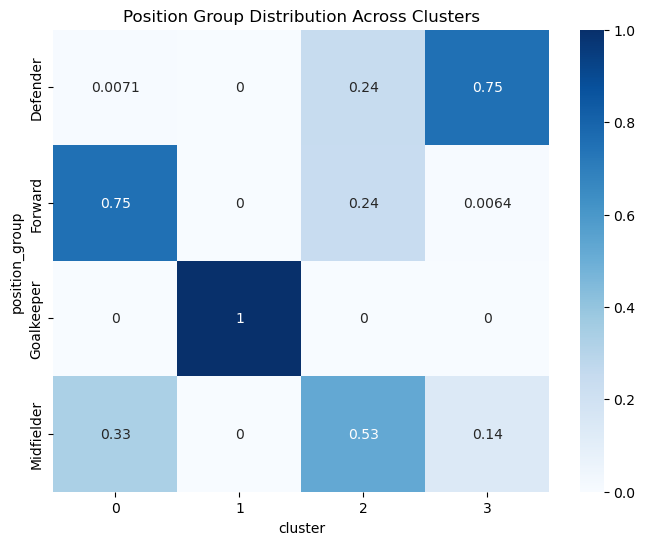

In [105]:
plt.figure(figsize=(8,6))
sns.heatmap(group_table, annot=True, cmap="Blues")
plt.title("Position Group Distribution Across Clusters")
plt.show()

# Hierarchical Agglomerative Clustering (HAC)

## Import Relevant Libraries

In [106]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram

## Dendrogram

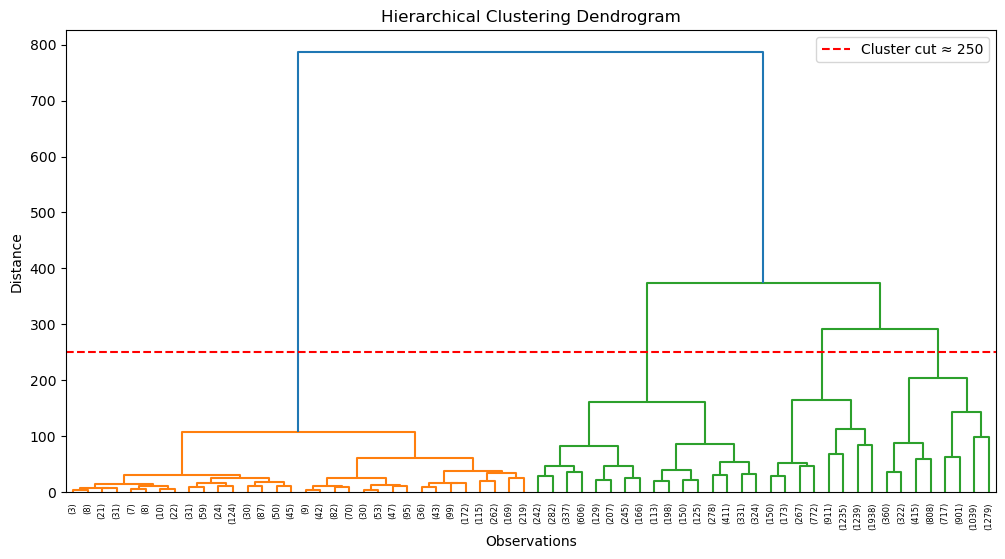

In [125]:
linked = linkage(X_pca, method='ward')

plt.figure(figsize=(12,6))
dendrogram(
    linked,
    truncate_mode='level',
    p=5
)

plt.axhline(y=250, color='red', linestyle='--', label='Cluster cut ≈ 250')

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.legend()
plt.show()

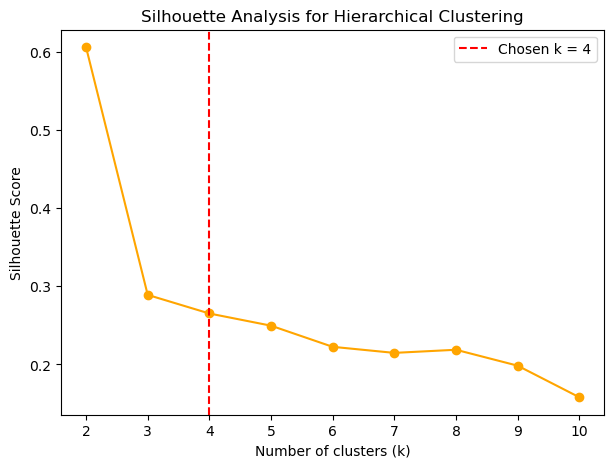

k=2: silhouette=0.606
k=3: silhouette=0.289
k=4: silhouette=0.265
k=5: silhouette=0.250
k=6: silhouette=0.222
k=7: silhouette=0.215
k=8: silhouette=0.219
k=9: silhouette=0.198
k=10: silhouette=0.158


In [124]:
k_values = range(2, 11)
hac_sil_scores = []

for k in k_values:
    hac = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hac.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    hac_sil_scores.append(score)

plt.figure(figsize=(7,5))
plt.plot(k_values, hac_sil_scores, marker='o', color='orange')
plt.axvline(x=4, color='red', linestyle='--', label='Chosen k = 4')

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis for Hierarchical Clustering")
plt.legend()
plt.show()

for k, s in zip(k_values, hac_sil_scores):
    print(f"k={k}: silhouette={s:.3f}")

## Fit HAC model 

In [79]:
k_hac = 4

hac = AgglomerativeClustering(
    n_clusters=k_hac,
    linkage='ward'
)

hac_labels = hac.fit_predict(X_pca)

## Cluster Metrics

In [122]:
print("HAC Silhouette Score:", silhouette_score(X_pca, hac_labels))
print("HAC Davies-Bouldin Index:", davies_bouldin_score(X_pca, hac_labels))
print("HAC Calinski-Harabasz Score:", calinski_harabasz_score(X_pca, hac_labels))

HAC Silhouette Score: 0.2840632406612474
HAC Davies-Bouldin Index: 1.2015435909757943
HAC Calinski-Harabasz Score: 14637.797027505092


## Visualize Clusters in PCA Space

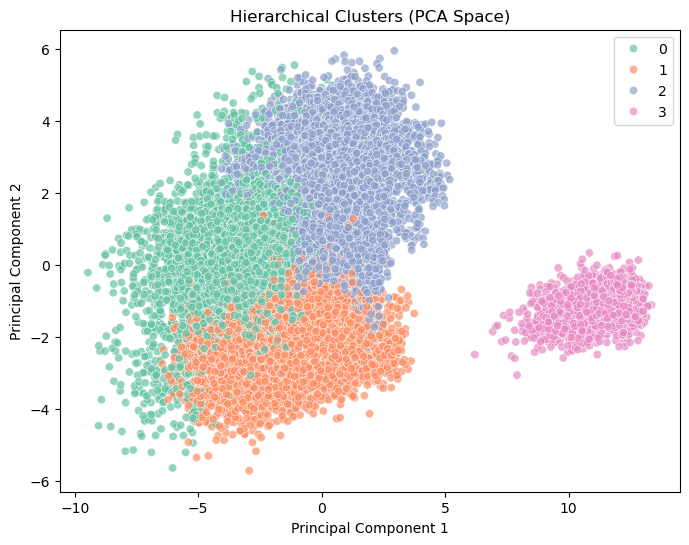

In [81]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=hac_labels,
    palette="Set2",
    alpha=0.7
)

plt.title("Hierarchical Clusters (PCA Space)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## Cluster Size Distribution

0    5573
1    5722
2    5375
3    2103
Name: count, dtype: int64


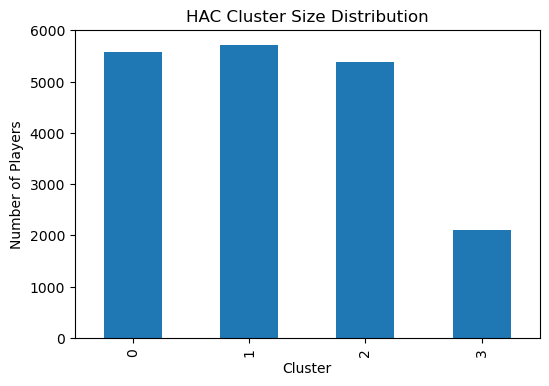

In [82]:
hac_counts = pd.Series(hac_labels).value_counts().sort_index()
print(hac_counts)

plt.figure(figsize=(6,4))
hac_counts.plot(kind='bar')
plt.title("HAC Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Players")
plt.show()

## Profiling Using Original Variables

In [83]:
data_hac = data.copy()
data_hac["cluster"] = hac_labels

hac_profile = data_hac.groupby("cluster")[features].mean().round(2)
hac_profile

,weak_foot,skill_moves,international_reputation,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,...,penalties,composure,defensive_awareness,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
cluster,,,,,,,,,,,,,,,,,,,,,
0,3.12,2.74,1.23,62.83,56.34,57.96,69.75,51.46,67.91,61.58,...,54.24,66.66,61.68,64.21,61.31,10.31,10.34,10.34,10.34,10.32
1,3.10,2.81,1.00,53.38,62.47,53.46,60.80,54.97,65.10,54.86,...,58.59,59.74,31.26,32.66,30.19,10.17,10.16,10.19,10.14,10.11
2,2.77,2.05,1.00,44.32,33.51,58.30,58.20,32.21,50.44,39.12,...,40.05,53.92,59.98,62.67,60.79,10.19,10.20,10.10,10.13,10.12
3,2.52,1.00,1.07,13.52,9.98,13.58,28.46,10.30,12.97,14.15,...,17.83,39.21,12.23,13.44,13.34,64.60,62.61,61.81,62.91,65.35


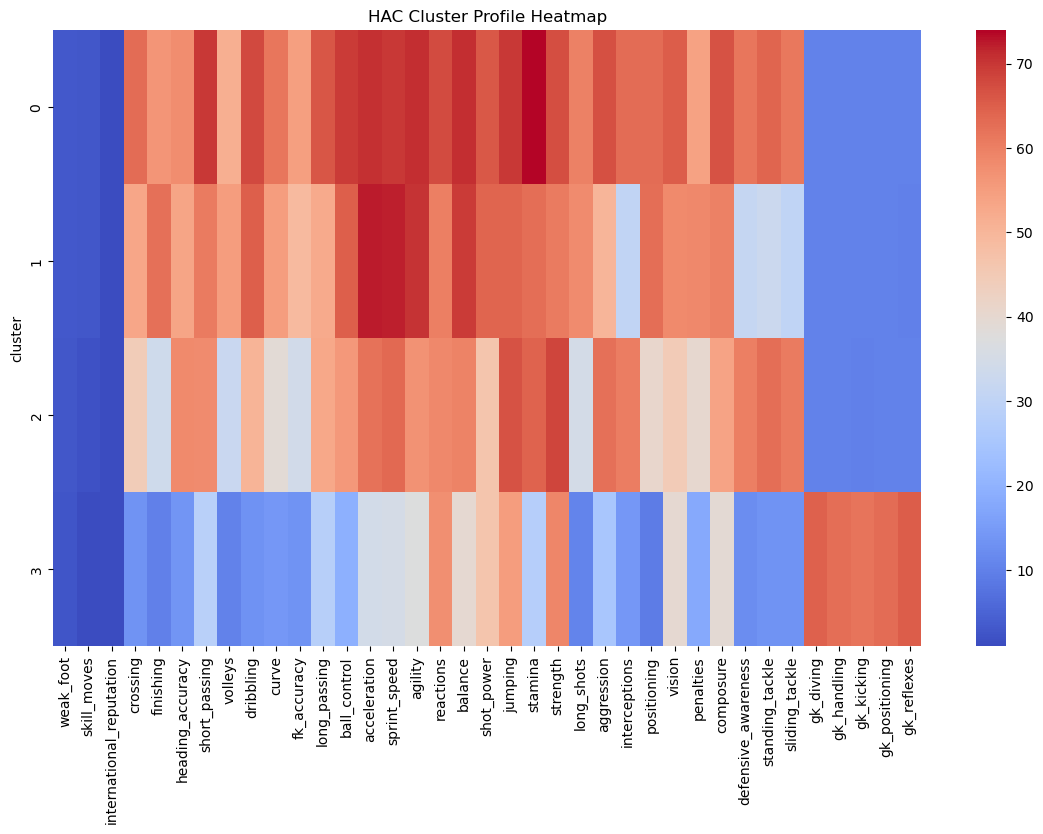

In [84]:
plt.figure(figsize=(14,8))
sns.heatmap(hac_profile, cmap="coolwarm")
plt.title("HAC Cluster Profile Heatmap")
plt.show()

## Validate Clusters with Actual Positions 

In [85]:
df_hac = df.loc[data.index].copy()
df_hac["cluster"] = hac_labels

def map_position_group(pos):
    if pos == "GK":
        return "Goalkeeper"
    elif pos in ["CB","LB","RB","LWB","RWB"]:
        return "Defender"
    elif pos in ["CDM","CM","CAM","LM","RM"]:
        return "Midfielder"
    elif pos in ["ST","CF","LW","RW"]:
        return "Forward"
    else:
        return "Other"

df_hac["position_group"] = df_hac["best_position"].apply(map_position_group)

hac_group_table = pd.crosstab(
    df_hac["position_group"],
    df_hac["cluster"],
    normalize="index"
)

hac_group_table

cluster,0,1,2,3
position_group,,,,
Defender,0.291579,0.006118,0.702302,0.0
Forward,0.087516,0.906692,0.005792,0.0
Goalkeeper,0.000000,0.000000,0.000000,1.0
Midfielder,0.474765,0.389879,0.135356,0.0


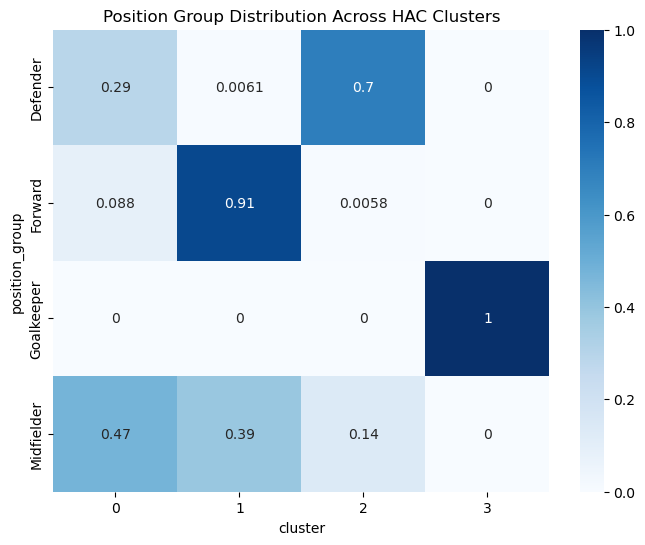

In [86]:
plt.figure(figsize=(8,6))
sns.heatmap(hac_group_table, annot=True, cmap="Blues")
plt.title("Position Group Distribution Across HAC Clusters")
plt.show()

# Comparing The Models 


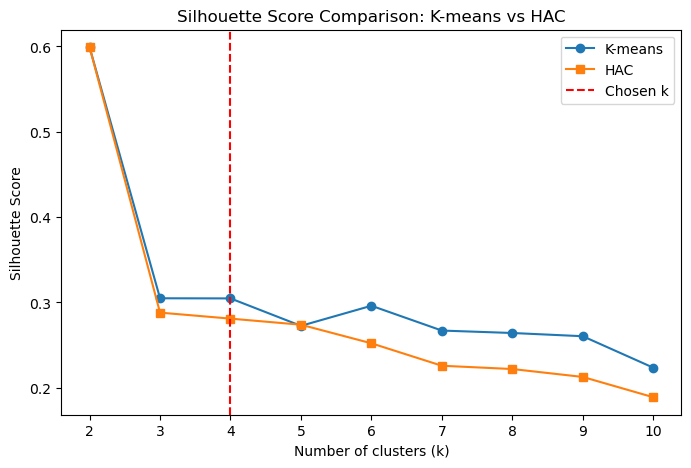

In [87]:
k_values = range(2, 11)

sil_kmeans = []
sil_hac = []

for k in k_values:
    
    # KMEANS
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_km = km.fit_predict(X_pca)
    sil_kmeans.append(silhouette_score(X_pca, labels_km))
    
    # HAC
    hac = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_hac = hac.fit_predict(X_pca)
    sil_hac.append(silhouette_score(X_pca, labels_hac))


plt.figure(figsize=(8,5))

plt.plot(k_values, sil_kmeans, marker='o', label='K-means')
plt.plot(k_values, sil_hac, marker='s', label='HAC')

plt.axvline(x=4, color='red', linestyle='--', label='Chosen k')

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Comparison: K-means vs HAC")
plt.legend()
plt.show()

# Regression Model


## Reading and importing libraries



In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error


In [187]:
df = pd.read_csv("new-players-data-full.csv")

df.head()

,player_slug,version,name,full_name,description,image,height_cm,weight_kg,dob,positions,...,composure,defensive_awareness,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes,play_styles
0,rodrigo-hernandez-cascante,2025-07-17,Rodri,Rodrigo Hernández Cascante,Rodri (born 22 June 1996) is a Spanish footbal...,https://cdn.sofifa.net/players/231/866/25_120.png,190,82,1996-06-22,"CDM,CM",...,94,92,87,82,10,10,7,14,8,"Tiki Taka +,Power Shot,Long Ball Pass,Bruiser,..."
1,mohamed-salah,2025-07-17,Mohamed Salah Hamed Ghaly,Mohamed Salah Hamed Ghalyمحمد صلاح,"Mohamed Salah (Mohamed Salah Hamed Ghaly, born...",https://cdn.sofifa.net/players/209/331/25_120.png,175,72,1992-06-15,"RM,RW",...,93,38,43,41,14,14,9,11,14,"Finesse Shot +,Chip Shot,Pinged Pass,Whipped C..."
2,jude-bellingham,2025-07-17,Jude Victor William Bellingham,Jude Victor William Bellingham,Jude Bellingham (Jude Victor William Bellingha...,https://cdn.sofifa.net/players/252/371/25_120.png,186,75,2003-06-29,"CAM,CM",...,87,77,79,77,14,11,10,5,8,"Relentless +,Intercept,Slide Tackle,Technical,..."
3,erling-haaland,2025-07-17,Erling Braut Håland,Erling Braut Håland,"Erling Haaland (Erling Braut Håland, born 21 J...",https://cdn.sofifa.net/players/239/085/25_120.png,195,94,2000-07-21,ST,...,88,38,47,29,7,14,13,11,7,"Chip Shot +,Power Shot,Power Header,Bruiser,Pr..."
4,vinicius-jose-de-oliveira-junior,2025-07-17,Vini Jr.,Vinicius José Paixão de Oliveira Junior,Vini Jr. (Vinicius José Paixão de Oliveira Jun...,https://cdn.sofifa.net/players/238/794/25_120.png,176,73,2000-07-12,"LW,ST",...,83,32,25,18,5,7,7,7,10,"Quick Step +,Finesse Shot,Chip Shot,Rapid,Flai..."


## Replacing string in values column to float64 

In [189]:
df["value"].astype(str).str[-1].value_counts()

value
0    18718
5       55
Name: count, dtype: int64

In [188]:
def convert_value(x):
    if isinstance(x, str):
        x = x.replace('€', '').strip()
        
        if 'M' in x:
            return float(x.replace('M', '')) * 1_000_000
        elif 'K' in x:
            return float(x.replace('K', '')) * 1_000
        else:
            return float(x)
    return x

df["value"] = df["value"].apply(convert_value)

print(df["value"].head())
print(df["value"].dtype)

0    115500000.0
1    104000000.0
2    174500000.0
3    157000000.0
4    171500000.0
Name: value, dtype: float64
float64


## Features for the model


In [190]:
df["dob"] = pd.to_datetime(df["dob"], errors="coerce")

current_year = 2025 

df["age"] = current_year - df["dob"].dt.year

features = [
    "age",
    "height_cm",
    "weight_kg",
    "overall_rating",
    "potential",
    "weak_foot",
    "skill_moves",
    "international_reputation",

    # attacking technical
    "crossing","finishing","heading_accuracy","short_passing","volleys",
    "dribbling","curve","fk_accuracy","long_passing","ball_control",

    # physical
    "acceleration","sprint_speed","agility","reactions","balance",
    "shot_power","jumping","stamina","strength","long_shots",

    # defensive
    "aggression","interceptions","positioning","vision","penalties",
    "composure","defensive_awareness","standing_tackle","sliding_tackle"
]

target = "value"

data = df[features + [target]].dropna().copy()

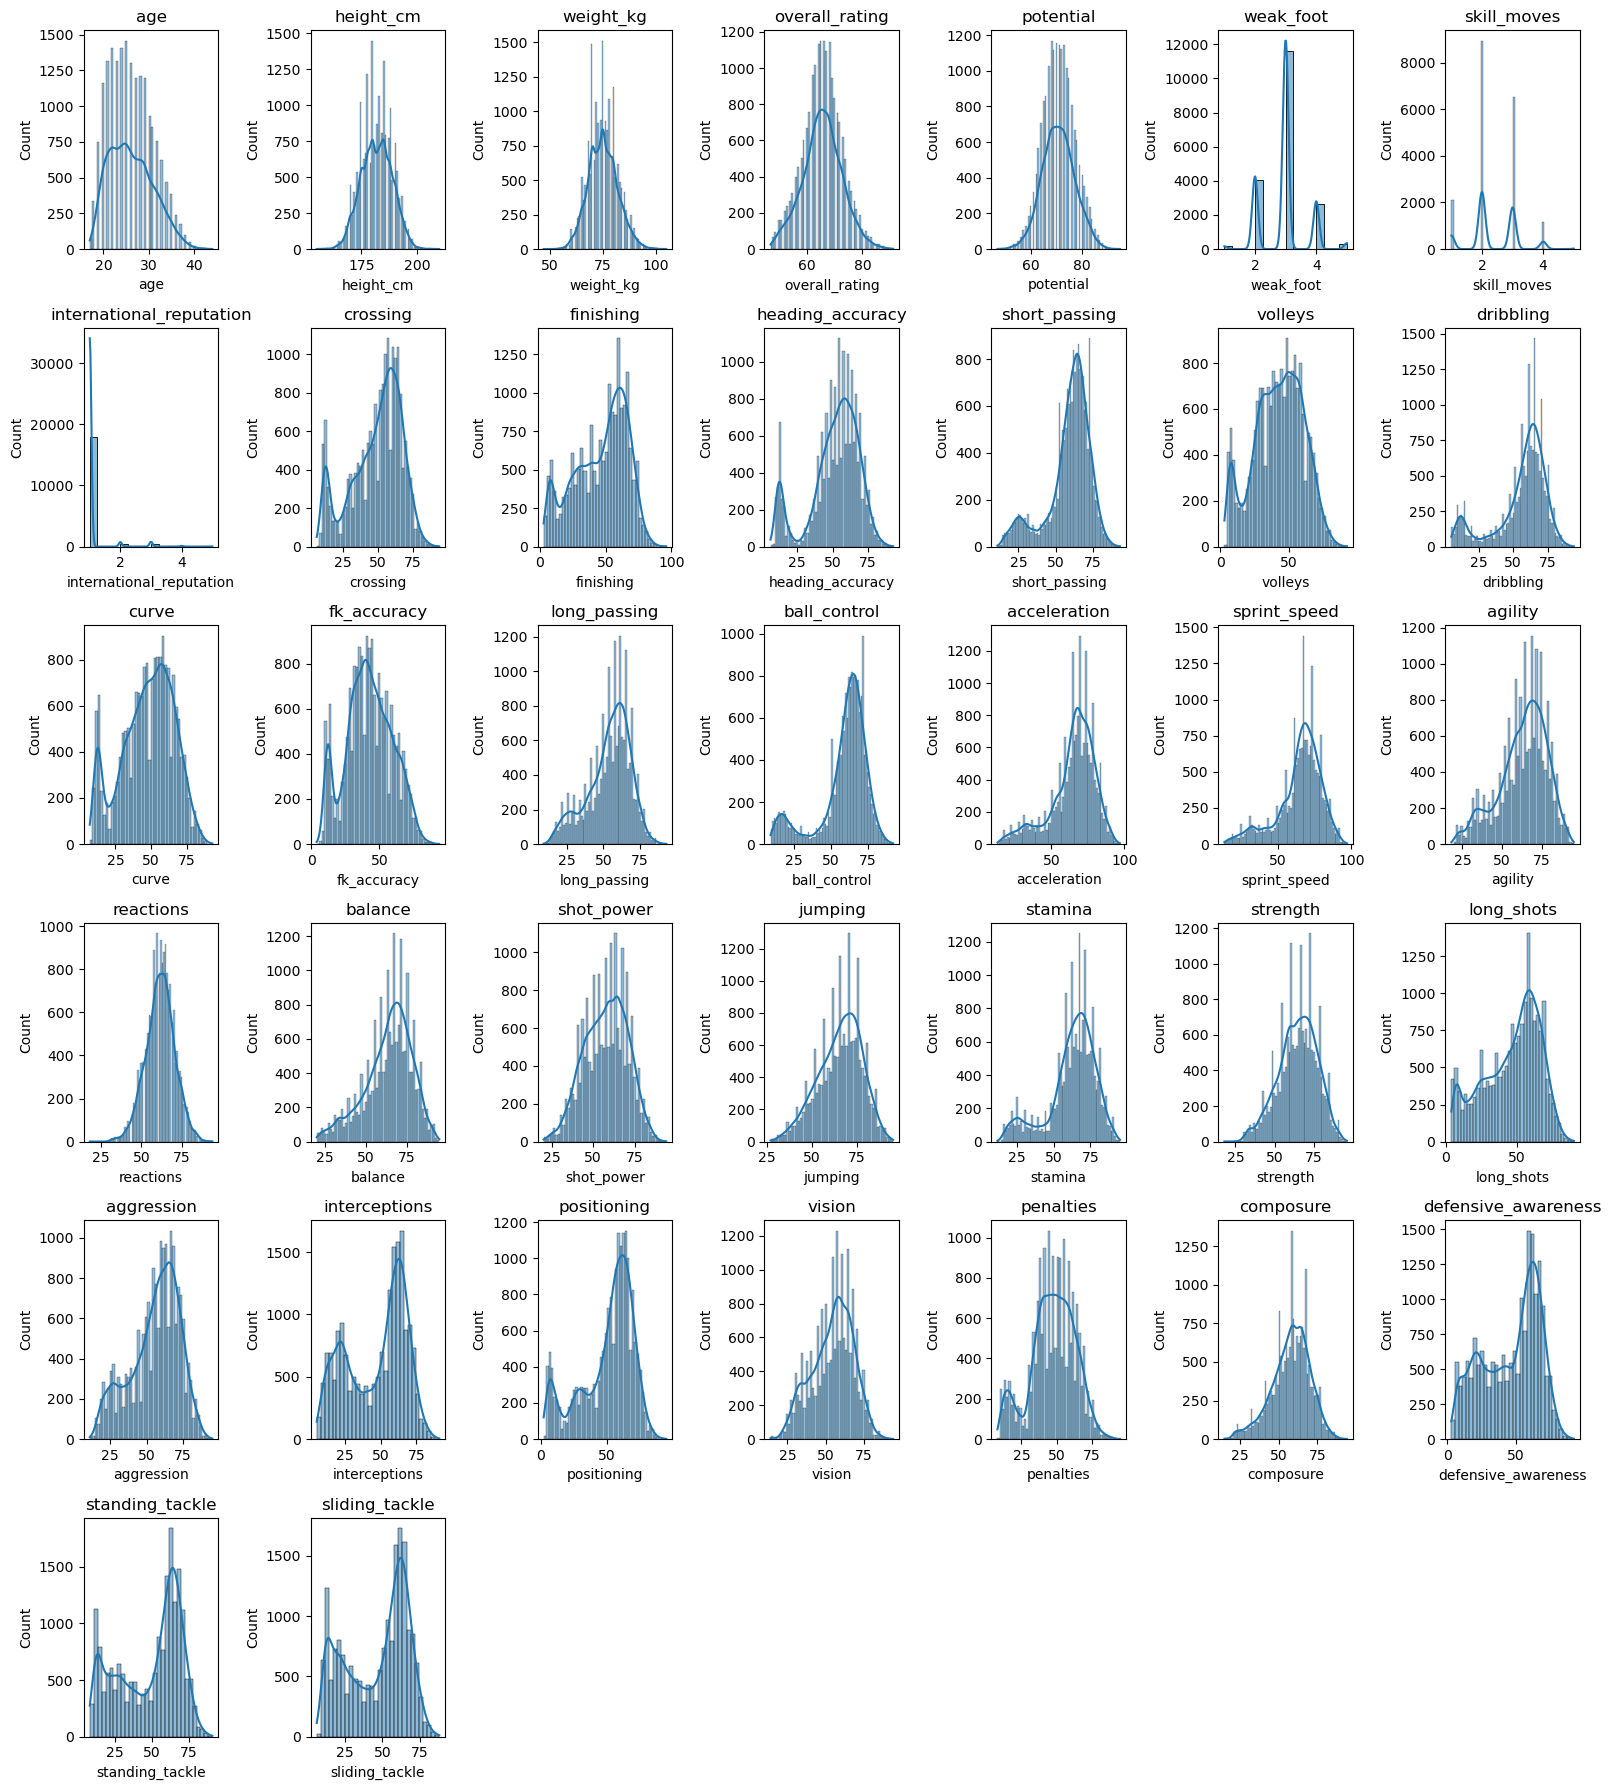

In [191]:
n_cols = 7
n_rows = math.ceil(len(features) / n_cols)

plt.figure(figsize=(16, n_rows * 3))

for i, col in enumerate(features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

## Splitting to train - test split

In [ ]:
X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Linear regression


In [203]:
def regression_plot(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    plt.figure(figsize=(6,5))
    plt.scatter(y_true, y_pred, alpha=0.5, color="royalblue")

    # regression line
    z = np.polyfit(y_true, y_pred, 1)
    p = np.poly1d(z)
    plt.plot(y_true, p(y_true), color="red")

    plt.title(f"{model_name}")
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")

    plt.text(
        0.05, 0.95,
        f"MAE = {mae:.2f}\nRMSE = {rmse:.2f}\nR² = {r2:.3f}",
        transform=plt.gca().transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle="round", facecolor="white")
    )

    plt.show()

    return mae, rmse, r2

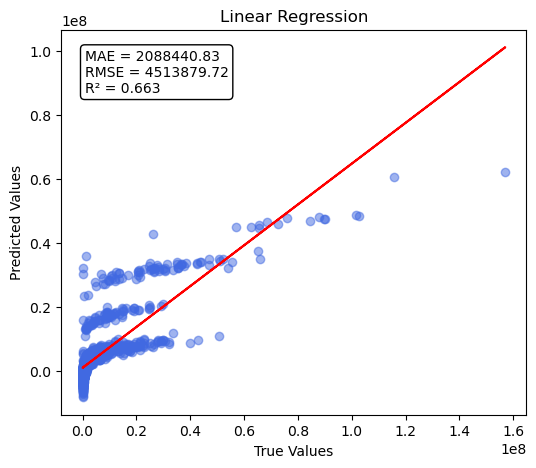

In [204]:
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)

y_pred_lin = lin_model.predict(X_test_scaled)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

mae_lin, rmse_lin, r2_lin = regression_plot(
    y_test,
    y_pred_lin,
    "Linear Regression"
)

## Polynomial regression

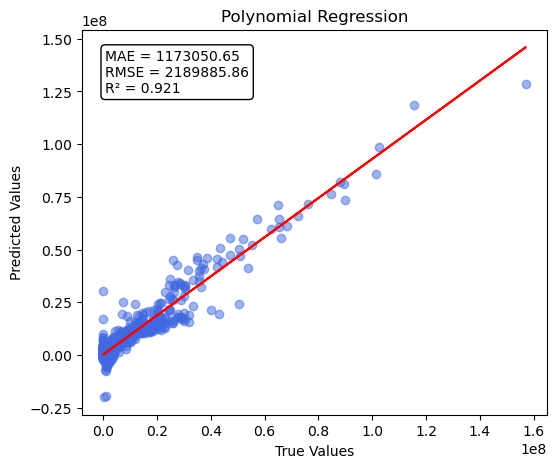

In [205]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

mae_poly, rmse_poly, r2_poly = regression_plot(
    y_test,
    y_pred_poly,
    "Polynomial Regression"
)

## Ridge regression

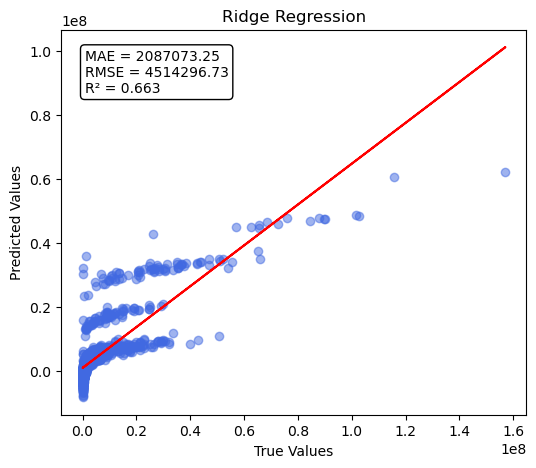

In [207]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=5)
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

mae_ridge, rmse_ridge, r2_ridge = regression_plot(
    y_test,
    y_pred_ridge,
    "Ridge Regression"
)

## Lasso regression

c:\Users\thund\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.536e+17, tolerance: 8.904e+13
  model = cd_fast.enet_coordinate_descent(


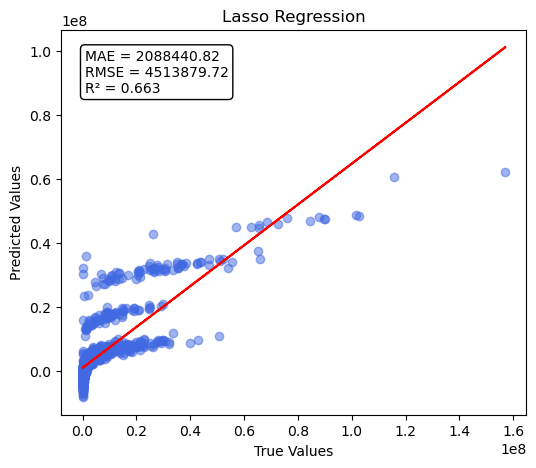

In [208]:
lasso_model = Lasso(alpha=0.001)
lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

mae_lasso, rmse_lasso, r2_lasso = regression_plot(
    y_test,
    y_pred_lasso,
    "Lasso Regression"
)

## Random forest

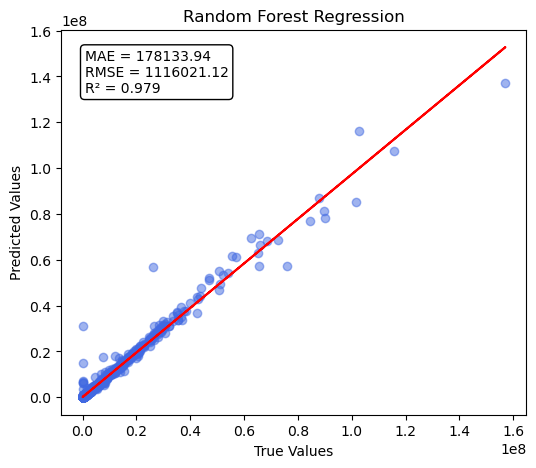

In [209]:
rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

mae_rf, rmse_rf, r2_rf = regression_plot(
    y_test,
    y_pred_rf,
    "Random Forest Regression"
)

## Comparing the different models

In [210]:
results = pd.DataFrame({
    "Model": ["Linear","Polynomial","Ridge","Lasso","Random Forest"],
    "MAE": [mae_lin, mae_poly, mae_ridge, mae_lasso, mae_rf],
    "RMSE": [rmse_lin, rmse_poly, rmse_ridge, rmse_lasso, rmse_rf],
    "R2": [r2_lin, r2_poly, r2_ridge, r2_lasso, r2_rf]
})

print(results.sort_values("RMSE"))

           Model           MAE          RMSE        R2
4  Random Forest  1.781339e+05  1.116021e+06  0.979419
1     Polynomial  1.173051e+06  2.189886e+06  0.920755
3          Lasso  2.088441e+06  4.513880e+06  0.663311
0         Linear  2.088441e+06  4.513880e+06  0.663311
2          Ridge  2.087073e+06  4.514297e+06  0.663249


C:\Users\thund\AppData\Local\Temp\ipykernel_22884\1839242467.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


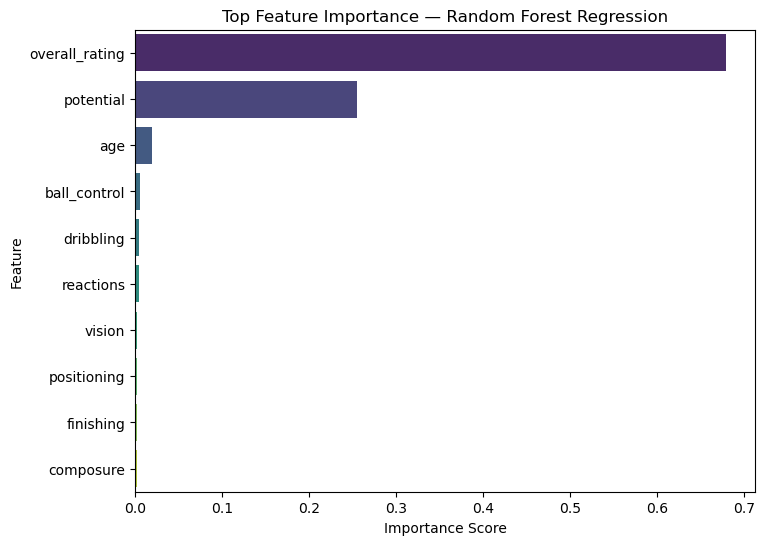

In [212]:
importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

feat_imp = feat_imp.sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(
    data=feat_imp.head(10),
    x="importance",
    y="feature",
    palette="viridis"
)

plt.title("Top Feature Importance — Random Forest Regression")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# Classification Model 

## Reading and importing libraries

In [139]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

In [148]:
df = pd.read_csv("mushrooms.csv")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [128]:
df["class"].value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

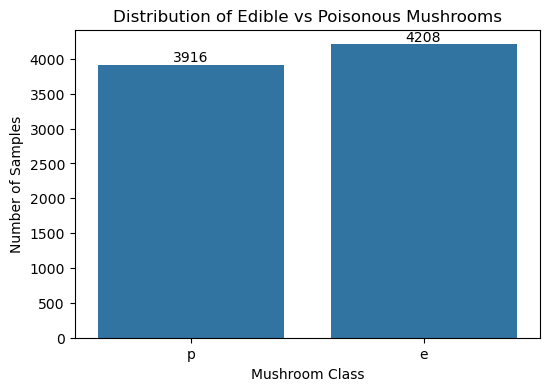

In [154]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="class"
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title("Distribution of Edible vs Poisonous Mushrooms")
plt.xlabel("Mushroom Class")
plt.ylabel("Number of Samples")

plt.show()

## Encode all the columns 


In [129]:
le = LabelEncoder()

df_encoded = df.apply(le.fit_transform)
df_encoded.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


## Define features and target

In [130]:
X = df_encoded.drop("class", axis=1)
y = df_encoded["class"]

## Train test split

In [131]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Standardise scale

In [132]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression

In [133]:
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9624615384615385
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       842
           1       0.96      0.96      0.96       783

    accuracy                           0.96      1625
   macro avg       0.96      0.96      0.96      1625
weighted avg       0.96      0.96      0.96      1625



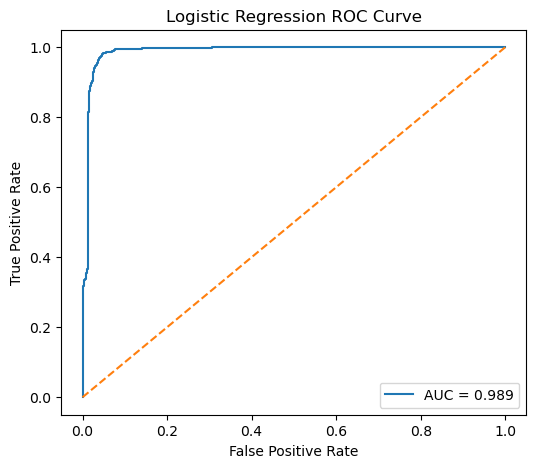

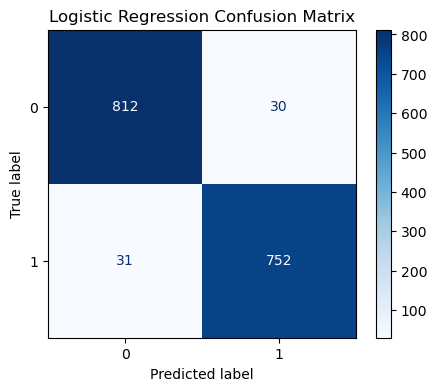

In [158]:
# probability
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]
y_pred_log = log_model.predict(X_test_scaled)

# ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)

plt.figure(figsize=(6,5))
plt.plot(fpr_log, tpr_log, label=f"AUC = {auc_log:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

# Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(cm_log)

fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Support Vector Classifier (SVC)


In [134]:
svc_model = SVC(kernel="rbf")

svc_model.fit(X_train_scaled, y_train)

y_pred_svc = svc_model.predict(X_test_scaled)

print("SVC Accuracy:", accuracy_score(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc))

SVC Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



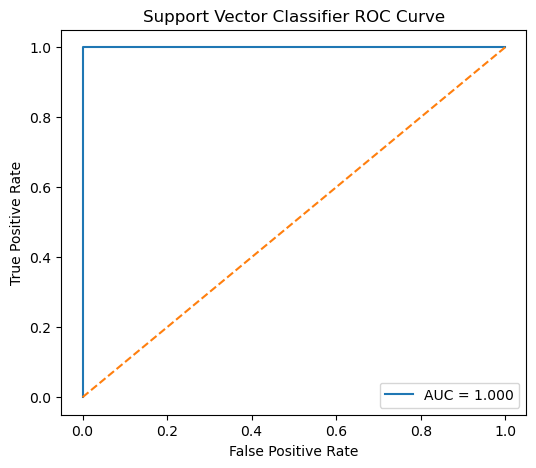

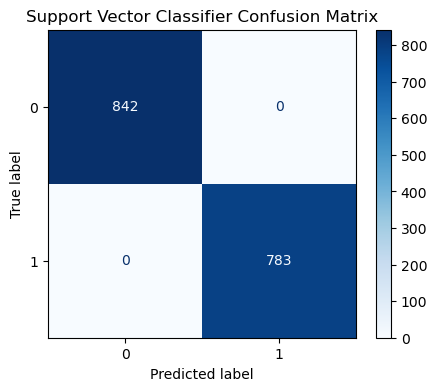

In [159]:
y_prob_svc = svc_model.predict_proba(X_test_scaled)[:,1]
y_pred_svc = svc_model.predict(X_test_scaled)

fpr_svc, tpr_svc, _ = roc_curve(y_test, y_prob_svc)
auc_svc = roc_auc_score(y_test, y_prob_svc)

plt.figure(figsize=(6,5))
plt.plot(fpr_svc, tpr_svc, label=f"AUC = {auc_svc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Support Vector Classifier ROC Curve")
plt.legend()
plt.show()

cm_svc = confusion_matrix(y_test, y_pred_svc)
disp = ConfusionMatrixDisplay(cm_svc)

fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, cmap="Blues")
plt.title("Support Vector Classifier Confusion Matrix")
plt.show()

## Random forest

In [135]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



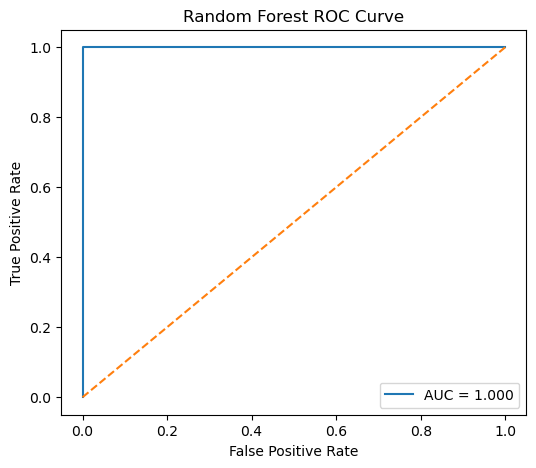

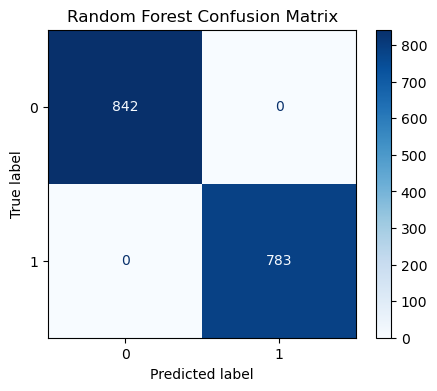

In [160]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
y_pred_rf = rf_model.predict(X_test)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {auc_rf:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm_rf)

fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

## Comparing models

In [136]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVC", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svc),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results.sort_values("Accuracy", ascending=False)

,Model,Accuracy
1,SVC,1.000000
2,Random Forest,1.000000
0,Logistic Regression,0.962462


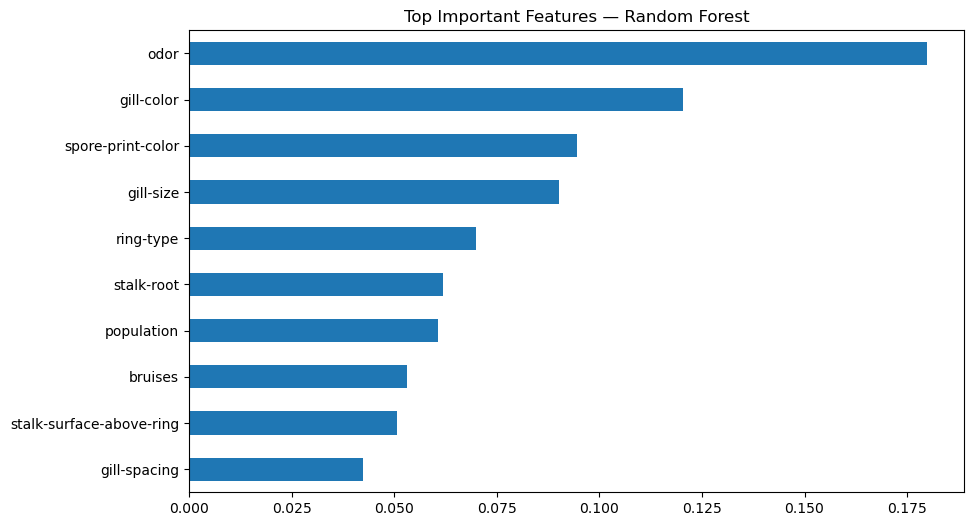

In [138]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(10).sort_values().plot(kind="barh")
plt.title("Top Important Features — Random Forest")
plt.show()

In [156]:
svc_model = SVC(kernel="rbf", probability=True, random_state=42)
svc_model.fit(X_train_scaled, y_train)
y_pred_svc = svc_model.predict(X_test_scaled)

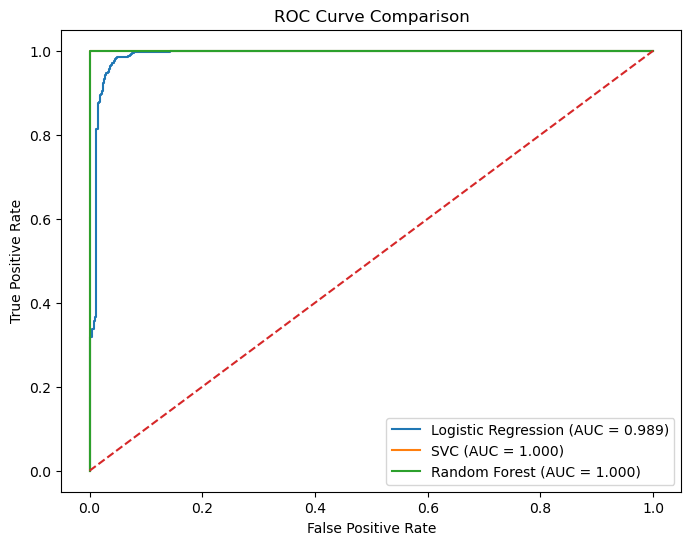

,Model,AUC
1,SVC,1.00000
2,Random Forest,1.00000
0,Logistic Regression,0.98872


In [155]:
# Logistic Regression probabilities
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# SVC probabilities
y_prob_svc = svc_model.predict_proba(X_test_scaled)[:, 1]

# Random Forest probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)

# SVC
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_prob_svc)
auc_svc = roc_auc_score(y_test, y_prob_svc)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_svc, tpr_svc, label=f"SVC (AUC = {auc_svc:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")

# diagonal reference line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

auc_results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVC", "Random Forest"],
    "AUC": [auc_log, auc_svc, auc_rf]
})

auc_results.sort_values("AUC", ascending=False)